# DeepGBoost Regressor

This notebook walks through a realistic regression workflow with `DeepGBoostRegressor`:

1. Fit on the California Housing dataset
2. Evaluate with R² and RMSE
3. Inspect per-feature contributions via `feature_contributions(X)`
4. Visualise feature importance with `plot_importance`
5. Use early stopping with an eval set

The contribution-based approach replaces the old `feature_importances_` attribute.
`feature_contributions(X)` returns `(bias, contributions)` where `contributions`
has shape `(n_samples, n_features)`. Global importance per feature is computed as
the mean of the absolute values across all samples.

In [1]:
fig, ax = plot_importance(
    reg,
    feature_names=feature_names,
    title="DeepGBoost — Feature Importance (California Housing)",
)
plt.show()

## 1. Load and split the data

In [2]:
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = list(data.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {feature_names}")

Training samples : 16512
Test samples     : 4128
Features         : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 2. Fit the regressor

We keep `n_layers × n_trees = 5 × 10 = 50` (well within the 100-unit budget).

In [3]:
reg = DeepGBoostRegressor(
    n_layers=5,
    n_trees=10,
    max_depth=4,
    learning_rate=0.3,
    random_state=42,
)

reg.fit(X_train, y_train)
print(reg)

DeepGBoostRegressor(learning_rate=0.3, max_depth=4, n_trees=10, random_state=42)


## 3. Evaluate on the test set

In [4]:
y_pred = reg.predict(X_test)

r2 = reg.score(X_test, y_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")

R²   : 0.6535
RMSE : 0.6738


## 4. Feature contributions

`feature_contributions(X)` decomposes each prediction into:
- **`bias`** — the model prior (mean of training targets), a scalar shared by all samples.
- **`contributions`** — an `(n_samples, n_features)` array where `contributions[i, j]`
  is the additive contribution of feature `j` to sample `i`'s prediction.

To obtain a single global importance score per feature (analogous to the old
`feature_importances_`), we take the mean of the absolute contributions across samples:

In [5]:
bias, contributions = reg.feature_contributions(X_train)

print(f"Bias (model prior): {bias:.4f}")
print(f"Contributions shape: {contributions.shape}")

# Global importance: mean absolute contribution per feature
importances = np.abs(contributions).mean(axis=0)

print("\nGlobal feature importances (mean |contribution|):")
for name, score in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"  {name:<12s}: {score:.4f}")

Bias (model prior): 2.0719
Contributions shape: (16512, 8)

Global feature importances (mean |contribution|):
  MedInc      : 0.4883
  AveOccup    : 0.1777
  Latitude    : 0.0930
  Longitude   : 0.0644
  HouseAge    : 0.0556
  AveRooms    : 0.0344
  AveBedrms   : 0.0018
  Population  : 0.0017


## 5. Visualise feature importance

`plot_importance` takes the fitted model and a sample matrix `X` as its first two
arguments. It calls `feature_contributions` internally and displays a horizontal
bar chart sorted by mean absolute contribution.

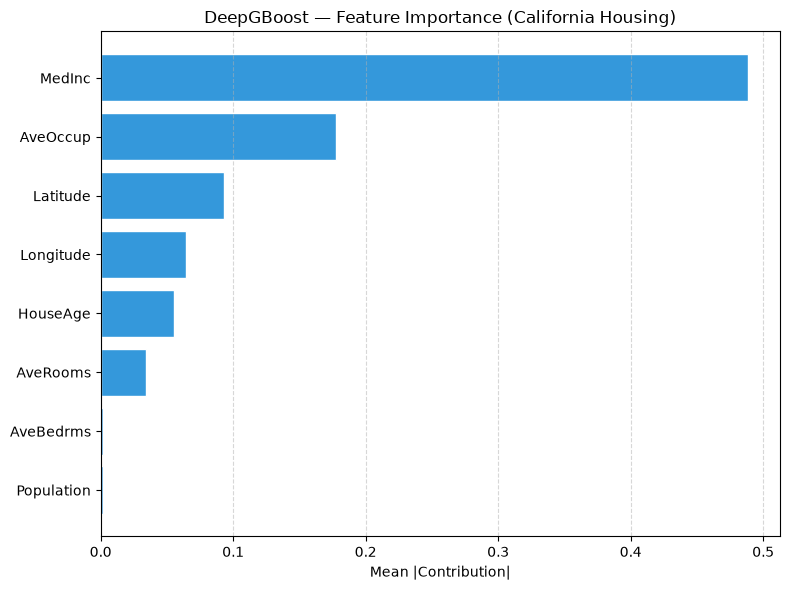

In [6]:
fig, ax = plot_importance(
    reg,
    feature_names=feature_names,
    title="DeepGBoost — Feature Importance (California Housing)",
)
plt.show()

## 6. Per-sample contribution waterfall (single prediction)

Because `contributions` is sample-level, we can also inspect exactly how each
feature pushed a specific prediction away from the prior.

In [7]:
sample_idx = 0
sample_pred = reg.predict(X_test[sample_idx : sample_idx + 1])[0]

_, test_contributions = reg.feature_contributions(
    X_test[sample_idx : sample_idx + 1],
)
sample_contribs = test_contributions[0]  # shape (n_features,)

print(f"Actual target       : {y_test[sample_idx]:.4f}")
print(f"Predicted value     : {sample_pred:.4f}")
print(f"Model prior (bias)  : {bias:.4f}")
print()
print("Per-feature contributions for this sample:")
for name, c in sorted(
    zip(feature_names, sample_contribs),
    key=lambda x: -abs(x[1]),
):
    sign = "+" if c >= 0 else ""
    print(f"  {name:<12s}: {sign}{c:.4f}")

Actual target       : 0.4770
Predicted value     : 1.0923
Model prior (bias)  : 2.0719

Per-feature contributions for this sample:
  MedInc      : -0.6719
  Latitude    : -0.1274
  Longitude   : -0.1006
  AveOccup    : -0.0785
  AveRooms    : -0.0021
  HouseAge    : -0.0006
  AveBedrms   : +0.0000
  Population  : +0.0000


## 7. Early stopping with an eval set

Pass `eval_set` during `fit` and set `early_stopping_rounds` to stop training
automatically when the validation loss stops improving.

In [8]:
reg_es = DeepGBoostRegressor(
    n_layers=10,
    n_trees=5,
    max_depth=4,
    learning_rate=0.3,
    early_stopping_rounds=3,
    random_state=42,
)

reg_es.fit(X_train, y_train, eval_set=[(X_test, y_test)])

print("Layers actually trained:", len(reg_es.model_.graph_))
print("Eval result keys      :", list(reg_es.evals_result_.keys()))

Layers actually trained: 10
Eval result keys      : ['eval_0']


Plot the validation loss curve recorded during training:

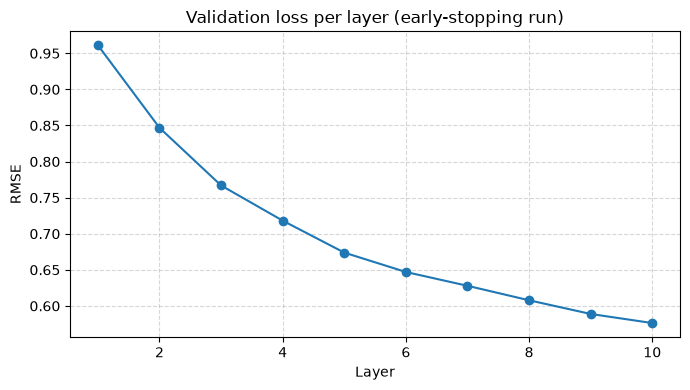

In [9]:
eval_name = list(reg_es.evals_result_.keys())[0]
losses = reg_es.evals_result_[eval_name]["train_loss"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(losses) + 1), losses, marker="o", linewidth=1.5)
ax.set_xlabel("Layer")
ax.set_ylabel("RMSE")
ax.set_title("Validation loss per layer (early-stopping run)")
ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()